# Lab on different optimizers 
**Dataset**: The network will be trained and tested using the MNIST dataset of handwritten digits (0–9).  It can be downloaded directly from Keras/Pytorch/TensorFlow, e.g- 
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data() 

**Data Splitting**: Randomly divide the dataset into train, validation, and test splits in a 60:20:20 
ratio. 
**Network Architecture**:  Two hidden layers, each with 200 neurons (you may change it 
according to your need) 
- Use a learning rate of 0.01 
- Use sigmoid as the activation function for hidden layers 
- Use softmax as the activation function for the output layer

**Optimizer Comparison**: 
Modify the experiment to use different optimizers and compare their performance: 
- Stochastic Gradient Descent (SGD) 
- Adam 
- RMSprop 
- Momentum-based Gradient Descent

Note- Weights(parameters) initialization should be same for every optimizer. Randomly 
initialize all the parameters once and store. Use these parameters for all different 
optimizer. 

**Evaluation**: 
Include plots of training and validation loss vs. epochs for each case 
Report the test accuracy for each architecture and optimizer 
Analyze and compare the impact of different optimizers on training speed and final accuracy 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
import copy
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
seed = 42
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

## Load and Split MNIST

In [2]:
# Transform: flatten + normalize to [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),            # [0,255]→[0,1]
    transforms.Normalize((0.5,), (0.5,))  # optional centering
])

# Download full training set (60k examples)
full_train = datasets.MNIST(root='.', train=True, download=True, transform=transform)
test_set  = datasets.MNIST(root='.', train=False, download=True, transform=transform)

# Split full_train → train (36k), val (12k), remaining 12k to match 60:20:20
n_train = int(0.6 * len(full_train))   # 36000
n_val   = int(0.2 * len(full_train))   # 12000
n_unused= len(full_train) - n_train - n_val  # 12000 (we could discard or merge)
train_set, val_set, _ = random_split(full_train, [n_train, n_val, n_unused],
                                     generator=torch.Generator().manual_seed(seed))

batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.40MB/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



## Define MLP and Initialize weights
2 hidden layers with 200 neurons + sigmoid activations

Grab one copy of the randomly initialized parameters (initial_state) to reload before each optimizer run

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=200, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.sig  = nn.Sigmoid()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.sig(self.fc1(x))
        x = self.sig(self.fc2(x))
        logits = self.fc3(x)
        # Note: we return raw logits for training with CrossEntropyLoss,
        # but you can apply self.softmax(logits) at inference.
        return logits

# Instantiate and capture initial weights
base_model = MLP().to(device)
initial_state = copy.deepcopy(base_model.state_dict())

## Traning and Validation
Using CrossEntropyLoss, which internally applies log_softmax + NLL, so we feed it raw logits.

In [4]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)            # CrossEntropyLoss
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
    return running_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
    avg_loss = running_loss / len(loader.dataset)
    acc = correct / len(loader.dataset)
    return avg_loss, acc

## Run experiments for each optimizer
Loop over each optimizer, reload the same initial parameters, train for 20 epochs, record losses, and finally measure test set accuracy

In [5]:
optimizers = {
    'SGD':      lambda params: optim.SGD(params,      lr=0.01),
    'SGD+Mom':  lambda params: optim.SGD(params,      lr=0.01, momentum=0.9),
    'RMSprop':  lambda params: optim.RMSprop(params,  lr=0.01),
    'Adam':     lambda params: optim.Adam(params,     lr=0.01),
}

num_epochs = 20
results = {}

for name, opt_fn in optimizers.items():
    # Reload initial weights
    model = MLP().to(device)
    model.load_state_dict(initial_state)
    optimizer = opt_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()
    
    train_losses, val_losses = [], []
    for epoch in range(1, num_epochs+1):
        tr_loss = train_epoch(model, train_loader, criterion, optimizer)
        va_loss, _  = eval_epoch(model, val_loader,   criterion)
        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        print(f"[{name}] Epoch {epoch}/{num_epochs} — train_loss: {tr_loss:.4f}, val_loss: {va_loss:.4f}")
    
    # Final test accuracy
    _, test_acc = eval_epoch(model, test_loader, criterion)
    
    results[name] = {
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'test_acc':     test_acc
    }
    print(f"→ {name} test accuracy: {test_acc*100:.2f}%\n")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
[SGD] Epoch 1/20 — train_loss: 2.2998, val_loss: 2.2941
[SGD] Epoch 2/20 — train_loss: 2.2911, val_loss: 2.2861
[SGD] Epoch 3/20 — train_loss: 2.2826, val_loss: 2.2781
[SGD] Epoch 4/20 — train_loss: 2.2717, val_loss: 2.2655
[SGD] Epoch 5/20 — train_loss: 2.2573, val_loss: 2.2489
[SGD] Epoch 6/20 — train_loss: 2.2373, val_loss: 2.2238
[SGD] Epoch 7/20 — train_loss: 2.2076, val_loss: 2.1886
[SGD] Epoch 8/20 — train_loss: 2.1633, val_loss: 2.1346
[SGD] Epoch 9/20 — train_loss: 2.0965, val_loss: 2.0540
[SGD] Epoch 10/20 — train_loss: 2.0001, val_loss: 1.9405
[SGD] Epoch 11/20 — train_loss: 1.8735, val_loss: 1.8027
[SGD] Epoch 12/20 — train_loss: 1.7269, val_loss: 1.6499
[SGD] Epoch 13/20 — train_loss: 1.5758, val_loss: 1.5014
[SGD] Epoch 14/20 — train_loss: 1.4343, val_loss: 1.3665
[SGD] Epoch 15/20 — train_loss: 1.3090, val_loss: 1.2496


## Plotting loss curves
Overlay all four optimizers’ curves to compare convergence speed and stability.

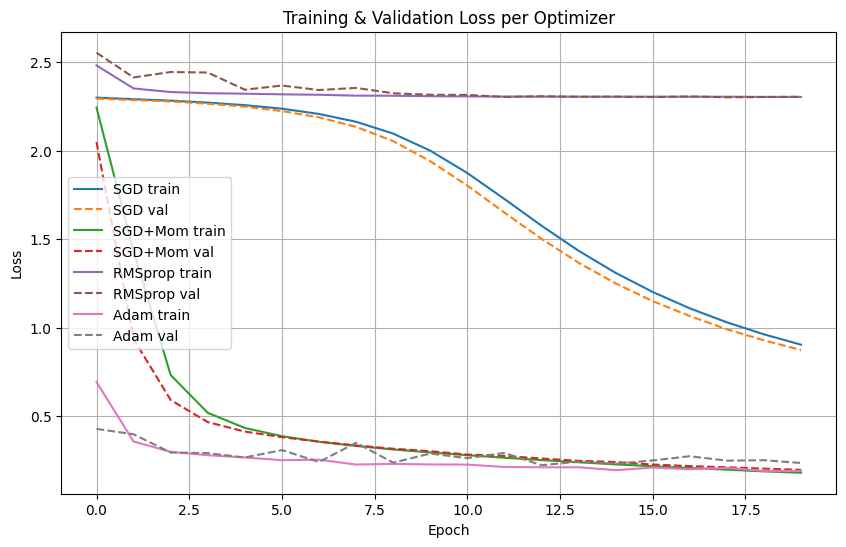

In [6]:
plt.figure(figsize=(10,6))
for name, res in results.items():
    plt.plot(res['train_losses'], label=f"{name} train")
    plt.plot(res['val_losses'],   label=f"{name} val", linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss per Optimizer")
plt.legend()
plt.grid(True)
plt.show()

## Reposting and Analysis

In [7]:
for name, res in results.items():
    print(f"{name:10s} — Test Accuracy: {res['test_acc']*100:.2f}%")

SGD        — Test Accuracy: 76.56%
SGD+Mom    — Test Accuracy: 94.60%
RMSprop    — Test Accuracy: 9.82%
Adam       — Test Accuracy: 93.66%
